# Backpropagation-based methods

In [1]:
from pathlib import Path

OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename):
    return OUT_DIR / filename


In [2]:
import torch
import torch.nn as nn
from torchvision import models

from torchvision import transforms
from PIL import Image

import matplotlib.pyplot as plt

## 1. Vanilla backpropagation

In [3]:
# Load a pre-trained resnet model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use device = xla.device() if you want to use tpu.
model = models.resnet18(pretrained=True).to(device)
# Set the model to evaluation mode
model.eval()

img_path = 'data/middle-dog.jpg'
input_image = Image.open(img_path)

# preprocessing for ResNet
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# set the ReLus to inplace = False
for i, (name, layer) in enumerate(model.named_modules()):
  if isinstance(layer, nn.ReLU):
    if name == "relu":
      getattr(model, name).inplace = False
    else:
      block, num, module = name.split(".")
      getattr(getattr(model,block)[int(num)], 'relu').inplace = False


# preprocess the image
input_tensor = preprocess(input_image)
# create a mini-batch as expected by the model
input_batch = input_tensor.unsqueeze(0)
################################################################################

print("Requires grad:", input_batch.requires_grad)
input_batch.requires_grad = True

output = model(input_batch)
top1_logit = output[0].max()  
top1_logit.backward()

print("Gradients:", input_batch.grad.shape)

/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Requires grad: False
Gradients: torch.Size([1, 3, 224, 224])


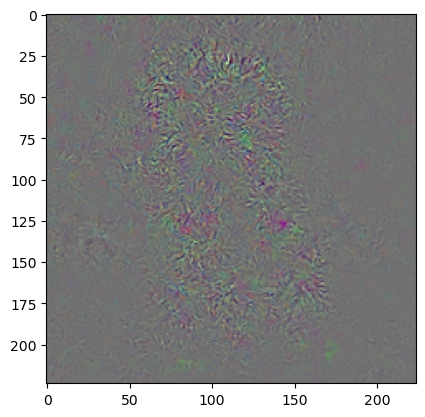

In [4]:
scaled_grad = input_batch.grad.squeeze(0).permute(1,2,0).detach().clone().numpy()
scaled_grad -= scaled_grad.min()
if scaled_grad.max() != 0:
    scaled_grad /= scaled_grad.max()

plt.imshow(scaled_grad)

## 2. Deconvolution backpropagation

Deconvolution backpropagation modifies the gradient computation in ReLU layers to focus on positive gradients. This involves replacing standard ReLU layers with custom ones that zero out negative gradients during the backward pass while maintaining consistent tensor dimensions throughout the model. 

In [5]:
# Load a pre-trained resnet model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use device = xla.device() if you want to use tpu.
model = models.resnet18(pretrained=True).to(device)
# Set the model to evaluation mode
model.eval()

img_path = 'data/middle-dog.jpg'
input_image = Image.open(img_path)

# preprocessing for ResNet
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# set the ReLus to inplace = False
for i, (name, layer) in enumerate(model.named_modules()):
  if isinstance(layer, nn.ReLU):
    if name == "relu":
      getattr(model, name).inplace = False
    else:
      block, num, module = name.split(".")
      getattr(getattr(model,block)[int(num)], 'relu').inplace = False


# preprocess the image
input_tensor = preprocess(input_image)
# create a mini-batch as expected by the model
input_batch = input_tensor.unsqueeze(0)

################################################################################
input_batch.requires_grad = True
print("Requires grad:", input_batch.requires_grad)

output = model(input_batch)
top1_logit = output[0].max()  
top1_logit.backward()


Requires grad: True


In [6]:
class reluDeconv(torch.autograd.Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """
    def __init__(self, inplace=False):
      super(reluDeconv, self).__init__()
      self.inplace = inplace

    @staticmethod
    def forward(ctx, input):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        ctx.save_for_backward(input)
        output = input.clamp(min=0) # output is max(0, input) : standard ReLU
        return output

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        grad_input = grad_output.clone() # We only pass back positive gradients. Negative gradients are set to zero.
        grad_input[grad_input < 0] = 0
        return grad_input


# what does this part do?
class reluDeconvWrapper(nn.Module):
    def __init__(self):
        super(reluDeconvWrapper, self).__init__()
    def forward(self, input):
        return reluDeconv.apply(input)

def replace_relu(model):
    for name, module in model.named_children():
        if isinstance(module, nn.ReLU):
            setattr(model, name, reluDeconvWrapper())
        else:
            replace_relu(module)

replace_relu(model)

input_batch.requires_grad = True
output = model(input_batch)
top1_logit, top1_idx = output[0].max(0)
top1_logit.backward()
print("Gradients shape:", input_batch.grad.shape)

Gradients shape: torch.Size([1, 3, 224, 224])


### Perform Min-Max feature scaling on the RGB gradient

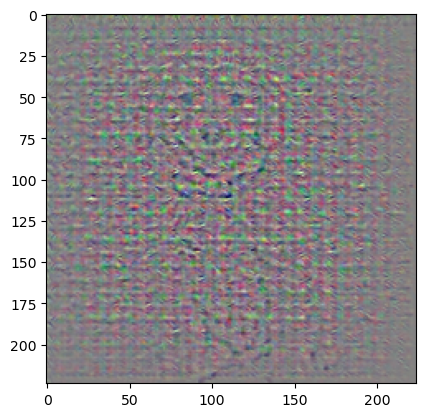

In [7]:
deconv_scaled_grad = input_batch.grad.squeeze(0).permute(1,2,0).detach().clone().numpy()
deconv_scaled_grad -= deconv_scaled_grad.min()
if deconv_scaled_grad.max() != 0:
    deconv_scaled_grad /= deconv_scaled_grad.max()

plt.imshow(deconv_scaled_grad)

## 3. Guided-backpropagation

This approach focuses on modifying the gradient computation specifically for the ReLU activation function, rather than reimplementing the entire backpropagation algorithm from scratch.

In [8]:
# Load a pre-trained resnet model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use device = xla.device() if you want to use tpu.
model = models.resnet18(pretrained=True).to(device)
# Set the model to evaluation mode
model.eval()

img_path = 'data/middle-dog.jpg'
input_image = Image.open(img_path)

# preprocessing for ResNet
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# set the ReLus to inplace = False
for i, (name, layer) in enumerate(model.named_modules()):
  if isinstance(layer, nn.ReLU):
    if name == "relu":
      getattr(model, name).inplace = False
    else:
      block, num, module = name.split(".")
      getattr(getattr(model,block)[int(num)], 'relu').inplace = False


# preprocess the image
input_tensor = preprocess(input_image)
# create a mini-batch as expected by the model
input_batch = input_tensor.unsqueeze(0)

################################################################################

In [9]:
class reluGuidedBackprop(torch.autograd.Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """
    def __init__(self, inplace=False):
      super(reluDeconv, self).__init__()
      self.inplace = inplace

    @staticmethod
    def forward(ctx, input):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        ctx.save_for_backward(input)
        output = input.clamp(min=0) # output is max(0, input) : standard ReLU
        return output

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        # Guided backpropagation: flow gradients only where input > 0 and grad_output > 0
        grad_input = grad_output.clone()
        inp = ctx.saved_tensors[0]
        grad_input[(inp <= 0) | (grad_output <= 0)] = 0
        return grad_input

class reluGuidedBackpropWrapper(nn.Module):
    def __init__(self):
        super(reluGuidedBackpropWrapper, self).__init__()
    def forward(self, input):
        return reluGuidedBackprop.apply(input)

def replace_relu(model):
    for name, module in model.named_children():
        if isinstance(module, nn.ReLU):
            setattr(model, name, reluGuidedBackpropWrapper())
        else:
            replace_relu(module)

replace_relu(model)

input_batch.requires_grad = True
output = model(input_batch)
top1_logit, top1_idx = output[0].max(0)
top1_logit.backward()
print("Gradients shape:", input_batch.grad.shape)

Gradients shape: torch.Size([1, 3, 224, 224])


### Perform Min-Max feature scaling on the RGB gradient.

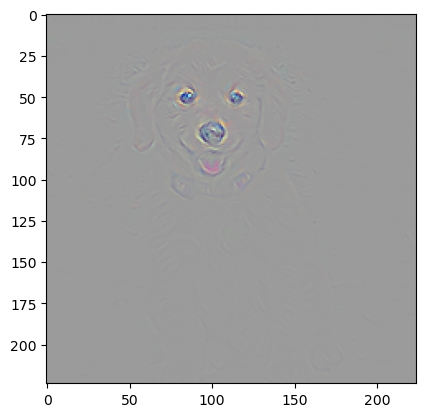

In [10]:
guided_scaled_grad = input_batch.grad.squeeze(0).permute(1,2,0).detach().clone().numpy()
guided_scaled_grad -= guided_scaled_grad.min()
if guided_scaled_grad.max() != 0:
    guided_scaled_grad /= guided_scaled_grad.max()
plt.imshow(guided_scaled_grad)

## 4. Comparison 

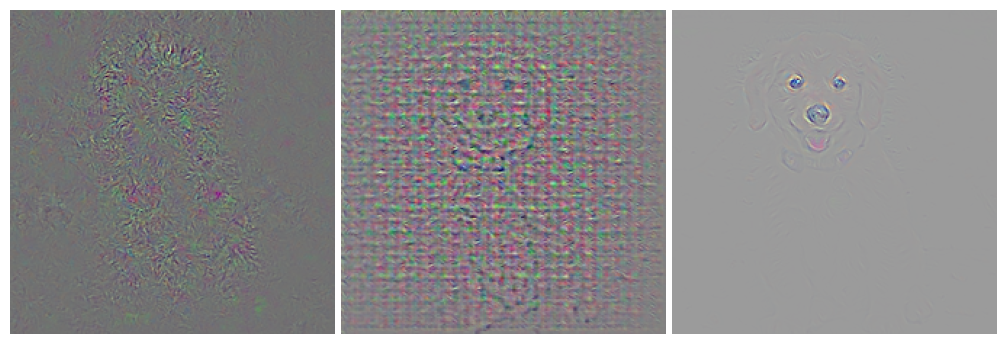

In [11]:
import matplotlib.pyplot as plt
import numpy as np # Assuming your variables are NumPy arrays

# Your variables are assumed to be defined here:
# scaled_grad
# deconv_scaled_grad
# guided_scaled_grad

# Example: If your variables were not already defined, you'd define them like this:
# image_height, image_width = 100, 100
# scaled_grad = np.random.rand(image_height, image_width)
# deconv_scaled_grad = np.random.rand(image_height, image_width)
# guided_scaled_grad = np.random.rand(image_height, image_width)


fig, axs = plt.subplots(1, 3, figsize=(10, 3.5)) # Slightly adjusted for a sleek look

# Original Gradient
axs[0].imshow(scaled_grad, cmap='gray') # Using 'gray' for classic elegance
axs[0].axis('off')

# Deconvolved Gradient
axs[1].imshow(deconv_scaled_grad, cmap='gray')
axs[1].axis('off')

# Guided Gradient
axs[2].imshow(guided_scaled_grad, cmap='gray')
axs[2].axis('off')

plt.tight_layout(pad=0.5) # Minimal padding for a tight, elegant fit

plt.savefig(out_path('comparison_backprop.pdf'), format='pdf', bbox_inches='tight', dpi=300) # High DPI for print quality
plt.show()